# Day 7: Neural Network Training Lab
This notebook demonstrates generating non-linear synthetic data, setting up a PyTorch data pipeline, training a Multi-Layer Perceptron (MLP), evaluating its convergence, and experimenting with hyperparameters.

In [55]:
import numpy as np

X = np.random.rand(1000, 2)
y = X[:, 0:1]**2 + 6 * X[:, 1:2] + np.random.randn(1000, 1) * 0.1

print(X[:5])
print(y[:5])

[[0.12470811 0.37846254]
 [0.78670514 0.18182867]
 [0.60861673 0.92138075]
 [0.49243481 0.98822193]
 [0.35454439 0.48650655]]
[[2.38981099]
 [1.78770798]
 [6.03895525]
 [6.06278398]
 [3.13601564]]


## Step 1: Exploratory Data Analysis
We check the shape, range, and statistical distributions of our generated variables to verify our setup.

In [56]:
print(X.shape)
print(y.shape)
print(X.min(axis=0))
print(y.min(axis =0))
print(y.mean())
print(y.std())


(1000, 2)
(1000, 1)
[0.00097301 0.00021119]
[0.01867853]
3.2712459528472517
1.7825016249021113


## Step 2: Data Splitting
Split our dataset into training (80%) and validation (20%) subsets to assess model generalization.

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size =0.2, random_state =10)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(800, 2)
(200, 2)
(800, 1)
(200, 1)


## Step 3: Tensor Conversion
Convert our NumPy arrays into PyTorch float tensors so they can be processed by neural network layers.

In [58]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)


print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)


torch.Size([800, 2])
torch.Size([200, 2])
torch.Size([800, 1])
torch.Size([200, 1])


## Step 4: Data Loaders
Wrap our datasets in PyTorch `TensorDataset` and `DataLoader` classes to enable efficient batching and shuffling.

In [59]:
from torch.utils.data import TensorDataset as td
from torch.utils.data import DataLoader as dl

train_dataset = td(X_train, y_train)
val_dataset = td(X_val, y_val)

print(len(train_dataset))
print(len(val_dataset))

train_loader = dl(train_dataset, batch_size = 32, shuffle = True)
val_loader = dl(val_dataset, batch_size = 32 , shuffle = False)


800
200


## Step 5: Batch Verification
Extract a single batch from the loaders to confirm that our input-output shapes match expectations.

In [60]:
X_batch, y_batch = next(iter(train_loader))

print(X_batch.shape)
print(y_batch.shape)

X_val_batch, y_val_batch = next(iter(val_loader))

print(X_val_batch.shape)
print(y_val_batch.shape)

torch.Size([32, 2])
torch.Size([32, 1])
torch.Size([32, 2])
torch.Size([32, 1])


## Step 6: Model Architecture
Define a classic 3-layer Multi-Layer Perceptron (MLP) mapping 2 input features to 1 continuous output using ReLU activations.

In [64]:
  import torch.nn as nn

  class NeuralNetwork(nn.Module):
    def __init__(self):
      super().__init__()
      self.model = nn.Sequential(
          nn.Linear(2,32),
          nn.ReLU(),
          nn.Linear(32,16),
          nn.ReLU(),
          nn.Linear(16, 1)
      )
    def forward(self, x):
      return self.model(x)

  model = NeuralNetwork()

  output = model(X_batch)
  print(output.shape)

torch.Size([32, 1])


## Step 7: Loss Function & Optimizer
We instantiate the Mean Squared Error (MSE) loss and setup the Adam optimizer.

In [67]:
  loss_fn = nn.MSELoss()

  loss = loss_fn(output, y_batch)
  print(loss)

tensor(15.8167, grad_fn=<MseLossBackward0>)


## Step 8: Single Optimization Step
Perform a quick forward and backward pass on a single batch to verify that gradient descent updates are working.

In [71]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [72]:
optimizer.zero_grad()

loss.backward()

optimizer.step()

In [75]:
output = model(X_batch)
loss = loss_fn(output, y_batch)
print(loss)

tensor(15.6928, grad_fn=<MseLossBackward0>)


## Step 9: Training Loop (Train Only)
Initial training loop over 100 epochs, tracking only our training MSE loss.

In [82]:
train_losses = []
epochs = 100

for epoch in range(epochs):
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

Epoch 10/100 - Loss: 0.0098
Epoch 20/100 - Loss: 0.0097
Epoch 30/100 - Loss: 0.0101
Epoch 40/100 - Loss: 0.0104
Epoch 50/100 - Loss: 0.0094
Epoch 60/100 - Loss: 0.0094
Epoch 70/100 - Loss: 0.0097
Epoch 80/100 - Loss: 0.0099
Epoch 90/100 - Loss: 0.0093
Epoch 100/100 - Loss: 0.0095


## Step 10: Training & Validation Loop
A refined training process that evaluates validation loss at the end of each epoch while disabling gradient tracking.

In [83]:
model = NeuralNetwork()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
epochs = 100

for epoch in range(epochs):
    # 1. Training Phase
    model.train()
    running_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # 2. Validation Phase
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_val_batch, y_val_batch in val_loader:
            val_output = model(X_val_batch)
            val_loss = loss_fn(val_output, y_val_batch)
            running_val_loss += val_loss.item()

    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

Epoch 10/100 | Train Loss: 0.6604 | Val Loss: 0.6202
Epoch 20/100 | Train Loss: 0.0268 | Val Loss: 0.0326
Epoch 30/100 | Train Loss: 0.0177 | Val Loss: 0.0206
Epoch 40/100 | Train Loss: 0.0157 | Val Loss: 0.0178
Epoch 50/100 | Train Loss: 0.0150 | Val Loss: 0.0164
Epoch 60/100 | Train Loss: 0.0145 | Val Loss: 0.0154
Epoch 70/100 | Train Loss: 0.0140 | Val Loss: 0.0147
Epoch 80/100 | Train Loss: 0.0136 | Val Loss: 0.0144
Epoch 90/100 | Train Loss: 0.0133 | Val Loss: 0.0137
Epoch 100/100 | Train Loss: 0.0127 | Val Loss: 0.0129


## Step 11: Plotting Loss Curves
Visualize training and validation loss trends over epochs to diagnose convergence, overfitting, or underfitting.

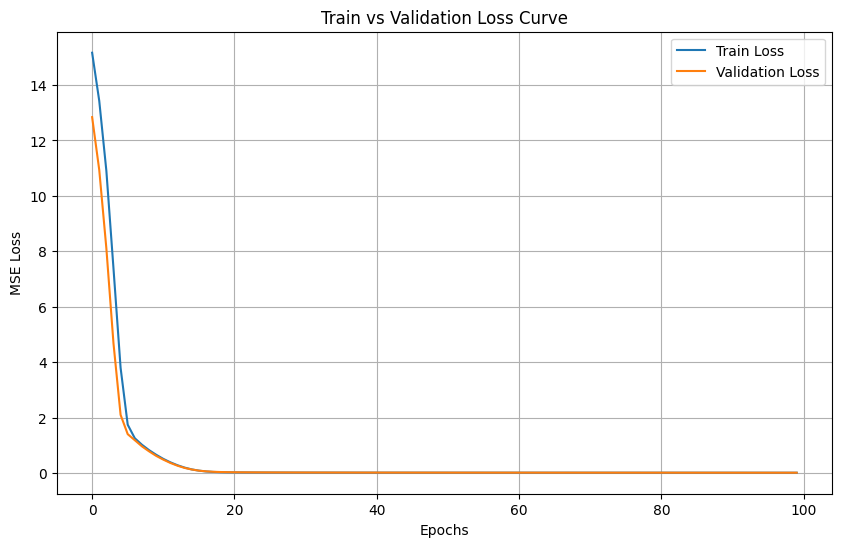

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Train vs Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

## Step 12: Testing on Unseen Data
Evaluate the trained network on the test subset to obtain our final generalization score.

In [86]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    test_loss = loss_fn(predictions, y_test_tensor)

print(f"Test MSE Loss: {test_loss.item():.4f}")

Test MSE Loss: 0.0122


## Step 13: Predictions Visualization
Plot actual values against predicted outputs on the test set. An optimal fit should align tightly along the diagonal.

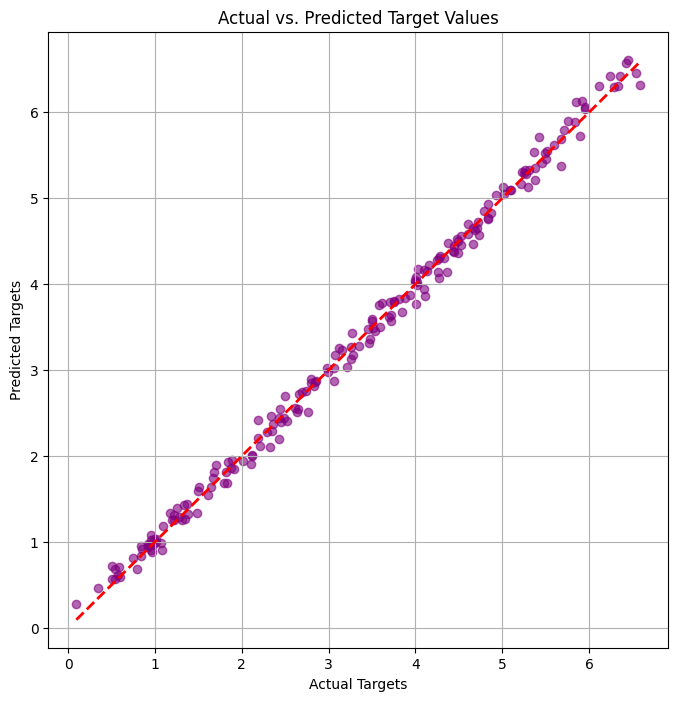

In [89]:
import matplotlib.pyplot as plt

with torch.no_grad():
    predictions_np = model(X_test_tensor).numpy()

plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions_np, alpha=0.6, color="purple")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Targets")
plt.ylabel("Predicted Targets")
plt.title("Actual vs. Predicted Target Values")
plt.grid(True)
plt.show()

## Step 14: Learning Rate Experiment
Train a second model with a high learning rate (`lr=0.05`) to observe how a large step size causes training instability.

In [91]:
exp_model = NeuralNetwork()
exp_optimizer = optim.Adam(exp_model.parameters(), lr=0.05)
exp_train_losses = []

for epoch in range(50):
    exp_model.train()
    running_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        output = exp_model(X_batch)
        loss = loss_fn(output, y_batch)

        exp_optimizer.zero_grad()
        loss.backward()
        exp_optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)
    exp_train_losses.append(epoch_train_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Exp Epoch {epoch+1}/50 | Train Loss: {epoch_train_loss:.4f}")

Exp Epoch 10/50 | Train Loss: 0.0158
Exp Epoch 20/50 | Train Loss: 0.0122
Exp Epoch 30/50 | Train Loss: 0.0211
Exp Epoch 40/50 | Train Loss: 0.0139
Exp Epoch 50/50 | Train Loss: 0.0169


## Step 15: Unified Training Pipeline
A clean, self-contained pipeline function consolidating model construction, training, validation, and testing.

In [92]:
def run_training_pipeline(lr=0.001, epochs=100):
    pipeline_model = NeuralNetwork()
    pipeline_optimizer = optim.Adam(pipeline_model.parameters(), lr=lr)

    for epoch in range(epochs):
        pipeline_model.train()
        for X_batch, y_batch in train_loader:
            output = pipeline_model(X_batch)
            loss = loss_fn(output, y_batch)
            pipeline_optimizer.zero_grad()
            loss.backward()
            pipeline_optimizer.step()

    pipeline_model.eval()
    with torch.no_grad():
        test_preds = pipeline_model(X_test_tensor)
        final_test_loss = loss_fn(test_preds, y_test_tensor)

    print(f"Pipeline complete. Final Test MSE: {final_test_loss.item():.4f}")

run_training_pipeline(lr=0.001, epochs=100)

Pipeline complete. Final Test MSE: 0.0111
